Simulation done.
Final positions:
 [[-0.09950534  1.        ]
 [-0.09950534  1.        ]
 [-0.09950534  1.        ]
 [-0.09950534  1.        ]]


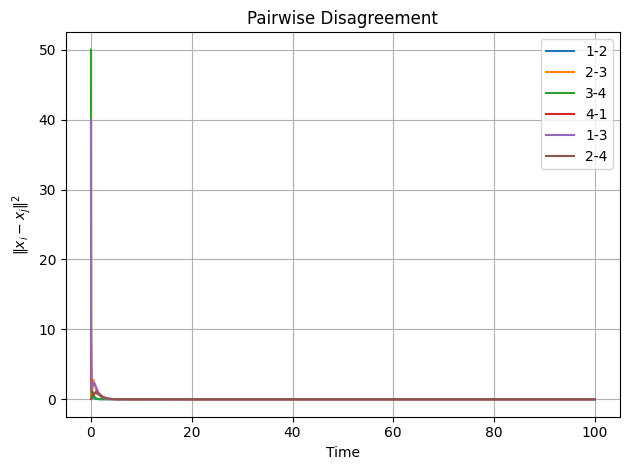

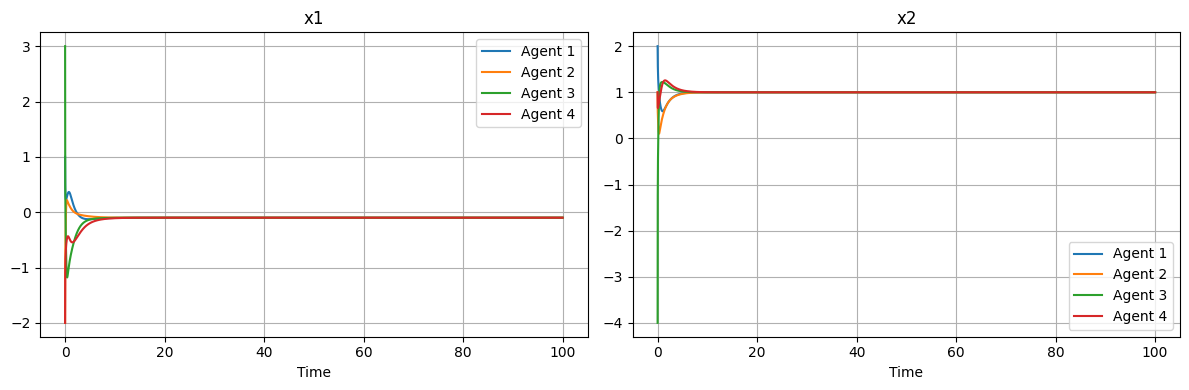

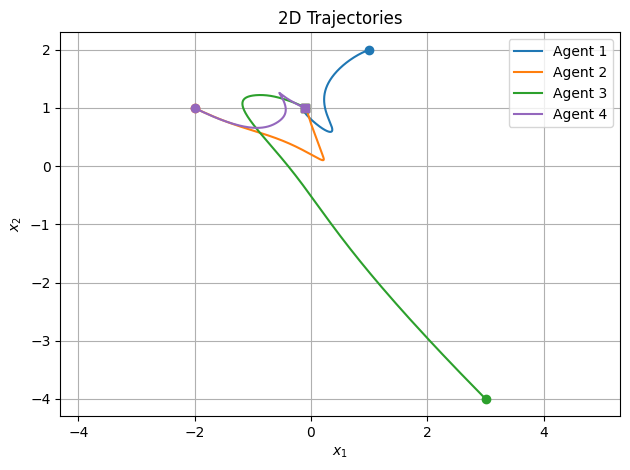

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ────────────────────────────────────────────────────────────────
N        = 4
T_final  = 100
dt       = 0.001
tvec     = np.arange(0, T_final + dt, dt)
steps    = len(tvec)
gamma1   = 1.0
gamma2   = 1.0

# ── Graph (square) ────────────────────────────────────────────────────────────
k=0.6
A =k* np.array([[0,1,0,1],
              [1,0,1,0],
              [0,1,0,1],
              [1,0,1,0]], dtype=float)
L = np.diag(A.sum(axis=1)) - A

# ── Initial states ────────────────────────────────────────────────────────────
x = np.array([[ 1.,  2.],
              [-2.,  1.],
              [ 3., -4.],
              [-2.,  1.]])
v     = np.zeros((N, 2))
alpha = np.zeros(N)

# ── Define GENERAL cost functions ─────────────────────────────────────────────
costs = []
grads = []

# Agent 1 → quadratic
t1 = np.array([2., 1.])
costs.append(lambda x: np.linalg.norm(x - t1)**2)
grads.append(lambda x: 2*(x - t1))

# Agent 2 → weighted quadratic
Q2 = np.array([[3.,0.],[0.,1.]])
costs.append(lambda x: x.T @ Q2 @ x)
grads.append(lambda x: 2 * Q2 @ x)

# Agent 3 → non-convex
costs.append(lambda x: np.sin(x[0]) + (x[1]-1)**2)
grads.append(lambda x: np.array([np.cos(x[0]), 2*(x[1]-1)]))

# Agent 4 → shifted quadratic
t4 = np.array([-2., 2.])
costs.append(lambda x: np.linalg.norm(x - t4)**2)
grads.append(lambda x: 2*(x - t4))

# ── Dynamics ──────────────────────────────────────────────────────────────────
def dyn_adaptive(x, v, alpha):
    Lx = L @ x
    Lv = L @ v

    x_dot     = np.zeros_like(x)
    v_dot     = np.zeros_like(v)
    alpha_dot = np.zeros(N)

    for i in range(N):
        g      = grads[i](x[i])        # ← generalized gradient
        e_i    = Lx[i]
        beta_i = float(e_i @ e_i)
        gain   = alpha[i] + beta_i

        v_dot[i]     = gamma1 * gain * e_i
        x_dot[i]     = -gamma2 * g - gamma1 * gain * e_i - Lv[i]
        alpha_dot[i] = beta_i

    return x_dot, v_dot, alpha_dot

# ── Simulation ────────────────────────────────────────────────────────────────
X_hist = np.zeros((N, 2, steps))

for k in range(steps):
    X_hist[:, :, k] = x
    x_dot, v_dot, alpha_dot = dyn_adaptive(x, v, alpha)

    x     = x + dt * x_dot
    v     = v + dt * v_dot
    alpha = alpha + dt * alpha_dot

print("Simulation done.")
print("Final positions:\n", X_hist[:, :, -1])

# ── Plot 1: Pairwise Disagreement ─────────────────────────────────────────────
pairs = [(0,1),(1,2),(2,3),(3,0),(0,2),(1,3)]

plt.figure()
for (i,j) in pairs:
    diff = X_hist[i,:,:] - X_hist[j,:,:]
    dij  = (diff**2).sum(axis=0)
    plt.plot(tvec, dij, linewidth=1.5, label=f'{i+1}-{j+1}')
plt.xlabel('Time')
plt.ylabel(r'$\|x_i - x_j\|^2$')
plt.title('Pairwise Disagreement')
plt.legend()
plt.grid(True)
plt.tight_layout()

# ── Plot 2: Components ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i in range(N):
    axes[0].plot(tvec, X_hist[i, 0, :], label=f'Agent {i+1}')
    axes[1].plot(tvec, X_hist[i, 1, :], label=f'Agent {i+1}')

for ax, title in zip(axes, ['x1', 'x2']):
    ax.set_xlabel('Time')
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

plt.tight_layout()

# ── Plot 3: Trajectories ──────────────────────────────────────────────────────
plt.figure()
colors = plt.cm.tab10(np.linspace(0, 0.4, N))

for i in range(N):
    traj = X_hist[i,:,:].T
    plt.plot(traj[:,0], traj[:,1], color=colors[i], label=f'Agent {i+1}')
    plt.plot(*traj[0], 'o', color=colors[i])
    plt.plot(*traj[-1], 's', color=colors[i])

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('2D Trajectories')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()

plt.show()